In [ ]:
from FluxSystem import FluxSystem
from Elements.Coil import Coil
from Elements.Shell import Shell
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import fluids as fl
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 4, pitch=6.35e-3)
print(coil.altura*1e3, coil.projected_d_out*1e3)

25.4 85.90179730350971


In [3]:
fluxsys = FluxSystem()
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic"))
fluxsys.add_singularity_loss(SingularityLoss(0.5))
fluxsys.add_coil(coil)
fluxsys.add_singularity_loss(SingularityLoss(0.5))
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic"))
fluxsys.conect()

In [4]:
T = 273.15 + 1.0  
P = 101325        
aumento_viscosidad = 1.33
fluido = 'Water'  
rho = cp.PropsSI('D', 'T', T, 'P', P, fluido)
mu = cp.PropsSI('V', 'T', T, 'P', P, fluido) * aumento_viscosidad

In [5]:
fluxsys.cross_system_pump(rho,mu, verbose=True);


═════════════════════════════════════════════
       🎯 PUNTO DE OPERACIÓN DEL SISTEMA      
═════════════════════════════════════════════
 🔹 Caudal volumétrico :    1.983 L/min
 🔹 Caudal másico      : 3.31e-05 m³/s
 🔹 Presión de cruce   :  17935.3 Pa
 🔹 Pérdida de altura  :    1.828 m.c.a.
═════════════════════════════════════════════



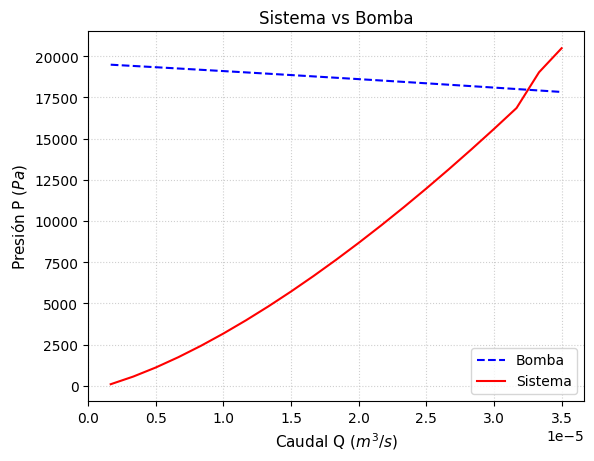

In [6]:
LPM_TO_M3S = 1 / 60000 

Q_test = np.arange(0.1 * LPM_TO_M3S, 15 * LPM_TO_M3S, 0.1 * LPM_TO_M3S)

P_system = np.zeros_like(Q_test)
P_pump = np.zeros_like(Q_test)
last_i = len(Q_test) - 1
for i in range(len(Q_test)):
    dh, dp = fluxsys.get_perdida_altura(Q_test[i], rho, mu)
    P_system[i] = dp
    P_pump[i] = LaudaPumpFit.Pa4m3s(Q_test[i])
    if dp >= 20000:
        last_i = i
        break

Q_plot = Q_test[:last_i+1]
P_system_plot = P_system[:last_i+1]
P_pump_plot = P_pump[:last_i+1]

# Dibujar curva ajustada
plt.plot(Q_plot, P_pump_plot, '--', color='blue', label='Bomba')
plt.plot(Q_plot, P_system_plot, '-', color='red', label = "Sistema")

plt.title('Sistema vs Bomba', fontsize=12)
plt.xlabel('Caudal Q ($m^3/s$)', fontsize=11)
plt.ylabel('Presión P ($Pa$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

